In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
def simulate_stochastic_qif(I_app, sigma, N, dt, V_th, V_reset):
    V = np.zeros(N)
    V[0] = V_reset
    spike_times = []
    
    for i in range(N - 1):
        # Deterministic drift
        drift = (V[i]**2 + I_app) * dt
        # Stochastic diffusion (Euler-Maruyama step)
        diffusion = sigma * np.sqrt(dt) * np.random.randn()
        
        V[i+1] = V[i] + drift + diffusion
        
        # Reset condition and spike logging
        if V[i+1] >= V_th:
            V[i+1] = V_reset
            V[i] = V_th # Pin peak for plotting
            spike_times.append(time[i])
            
    return V, np.array(spike_times)

In [3]:
# 1. Define Model Parameters
I_app_sub = -0.5    # Subthreshold current (for noise-induced spiking)
I_app_sup = 1.5     # Suprathreshold current (for ISI histogram)
sigmas = [2, 5]        # Noise intensity
V_th = 10.0         # Spike threshold
V_reset = -10.0     # Reset potential

# 2. Simulation Parameters
dt = 0.001
T_max = 50.0        # Longer time to gather enough spikes for the histogram
time = np.arange(0, T_max, dt)
N = len(time)

<>:19: SyntaxWarning: invalid escape sequence '\s'
<>:25: SyntaxWarning: invalid escape sequence '\s'
<>:19: SyntaxWarning: invalid escape sequence '\s'
<>:25: SyntaxWarning: invalid escape sequence '\s'
C:\Users\bielb\AppData\Local\Temp\ipykernel_20476\4268713920.py:19: SyntaxWarning: invalid escape sequence '\s'
  ax1.set_title(f'Noise-Induced Spiking ($I_{{app}}={I_app_sub}$, $\sigma={sigma}$)')
C:\Users\bielb\AppData\Local\Temp\ipykernel_20476\4268713920.py:25: SyntaxWarning: invalid escape sequence '\s'
  ax2.set_title(f'ISI Histogram ($I_{{app}}={I_app_sup}$, $\sigma={sigma}$)')


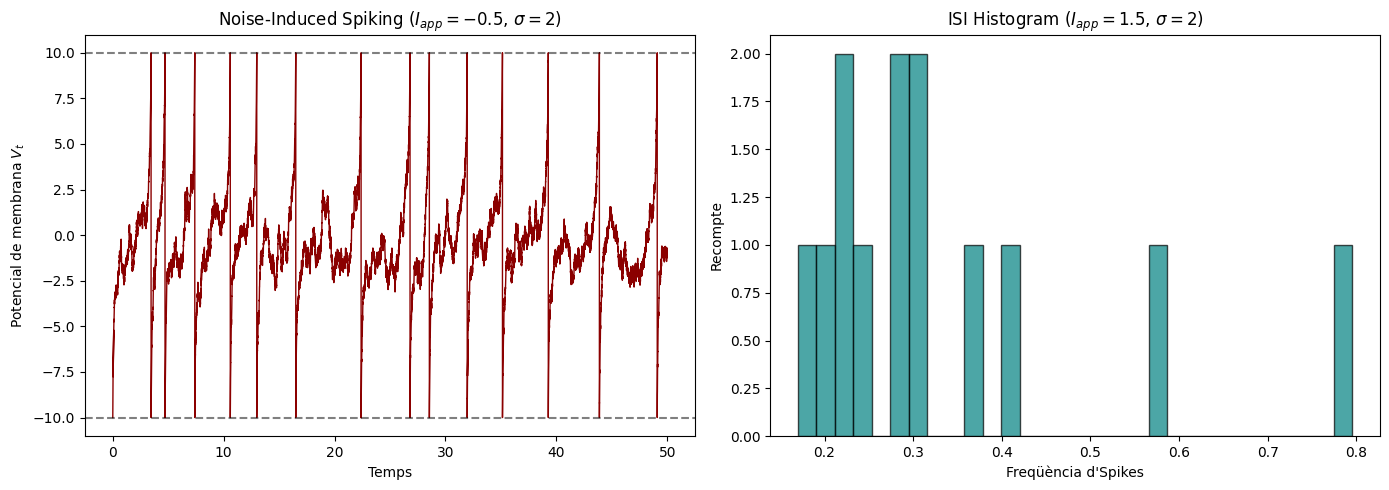

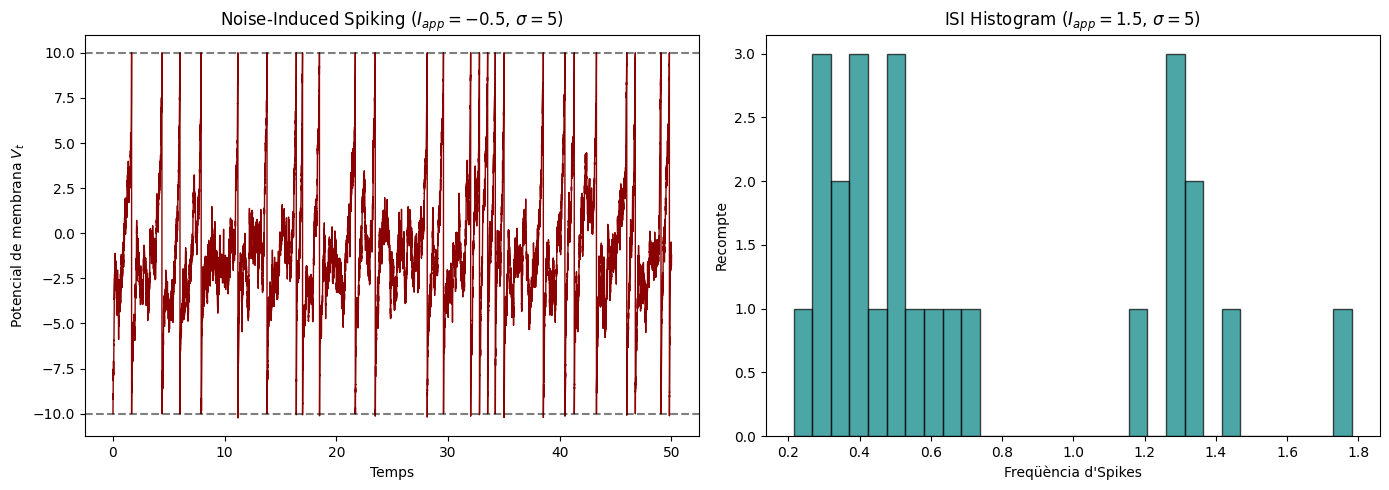

In [5]:
np.random.seed(123)

for sigma in sigmas:
    # 3. Run Simulations
    V_sub, spikes_sub = simulate_stochastic_qif(I_app_sub, sigma, N, dt, V_th, V_reset)
    V_sup, spikes_sup = simulate_stochastic_qif(I_app_sup, sigma, N, dt, V_th, V_reset)

    # Calculate ISIs (differences between consecutive spike times)
    freq_instantania = 1.0 / np.diff(spikes_sub)
    freq_mitjana = len(spikes_sub) / (time[-1] - time[0])

    # 4. Plotting
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    # Panel A: Noise-induced spiking
    ax1.plot(time, V_sub, color='darkred', lw=1)
    ax1.axhline(V_th, color='k', linestyle='--', alpha=0.5)
    ax1.axhline(V_reset, color='k', linestyle='--', alpha=0.5)
    ax1.set_title(f'Noise-Induced Spiking ($I_{{app}}={I_app_sub}$, $\sigma={sigma}$)')
    ax1.set_xlabel('Temps')
    ax1.set_ylabel('Potencial de membrana $V_t$')

    # Panel B: ISI Histogram
    ax2.hist(freq_instantania, bins=30, color='teal', edgecolor='black', alpha=0.7)
    ax2.set_title(f'ISI Histogram ($I_{{app}}={I_app_sup}$, $\sigma={sigma}$)')
    ax2.set_xlabel('Freqüència d\'Spikes')
    ax2.set_ylabel('Recompte')

    plt.tight_layout()
    plt.show()

In [12]:
I_app_gt = 1
sigma_gt = 2.0
V_th = 10.0
V_reset = -10.0

dt = 0.001
T_max = 50.0
time = np.arange(0, T_max, dt)
N = len(time)

In [13]:
V_gt, Spike_times_gt = simulate_stochastic_qif(I_app_gt, sigma_gt, N, dt, V_th, V_reset)

I_app = 0
sigma_squared = 0
for i in range(N - 1):
    I_app = I_app + V_gt[i + 1] - V_gt[i] - V_gt[i]**2 * dt

I_app = I_app / ((N - 1) * dt)

for i in range(N - 1):
    sigma_squared = sigma_squared + (V_gt[i + 1] - V_gt[i] - V_gt[i]**2 * dt - I_app * dt)**2

sigma_squared = np.sqrt(sigma_squared / ((N - 1)*dt))
sigma = np.sqrt(sigma_squared)

In [14]:
Error_I_app = np.abs(I_app - I_app_gt)
Error_sigma = np.abs(sigma - sigma_gt)

print(f"Estimated I_app: {I_app:.4f}, Error: {Error_I_app:.4f}")
print(f"Estimated sigma: {sigma:.4f}, Error: {Error_sigma:.4f}")

Estimated I_app: -6.8430, Error: 7.8430
Estimated sigma: 3.5869, Error: 1.5869
